<a href="https://colab.research.google.com/github/jayant003/B-Tech-Final-Year-Project-Tuberculosis-Detection-using-Deep-Learning/blob/main/Copy_of_Copy_of_Jayant_21082024(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!pip install scikit-image
from skimage import transform
from skimage import transform as skimage_transform
!pip install imutils
import imutils
import os
from imutils import paths
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras import layers
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
!pip install scikit-learn # Install scikit-learn if you haven't already
from sklearn.preprocessing import LabelBinarizer  # Import LabelBinarizer
from tensorflow.keras.utils import to_categorical # Import to_categorical

In [ ]:
!pip install tensorflow
import tensorflow as tf
!pip install imutils
from imutils import paths
import matplotlib.pyplot as plt
import argparse
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16,ResNet50,DenseNet121,Xception,DenseNet169
from tensorflow.keras.applications.inception_v3 import InceptionV3
from keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from keras import optimizers
from PIL import Image
from sklearn.model_selection import KFold
import cv2
import numpy as np
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from keras import applications as ap
from keras.applications.imagenet_utils import preprocess_input, decode_predictions
from keras.preprocessing import image
from keras.layers import Activation,LSTM,GRU,Reshape
from keras.layers import LSTM
# Try using a standard LSTM layer instead of CuDNNLSTM
# from keras.layers import Activation,LSTM,GRU,Reshape

In [ ]:
"""!pip install imutils
from imutils import paths
import matplotlib.pyplot as plt
import argparse
import os
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv1D,Conv2D,MaxPooling1D,MaxPooling2D
from keras.layers import Activation,LSTM,GRU,Reshape
from keras.layers import BatchNormalization
from tensorflow.keras.applications import VGG16,VGG19,ResNet50,DenseNet121,DenseNet169,Xception
from tensorflow.keras.applications.inception_v3 import InceptionV3
from keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from keras import optimizers
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy
from tensorflow.keras.utils import to_categorical
from keras.layers import LSTM
!pip install keras_metrics
import keras_metrics

In [ ]:
import os
Data_Dir = "/content/drive/MyDrive/700-700/"

In [ ]:
TBimages = os.listdir(Data_Dir+"Tuberculosis")
Nimages =  os.listdir(Data_Dir+"Normal")

Normal Chest X-Ray Vs Tuberculosis Chest X-Ray


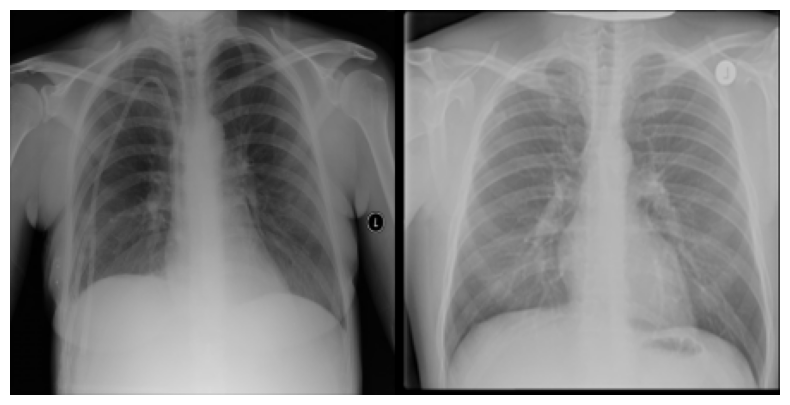

Normal Chest X-Ray Vs Tuberculosis Chest X-Ray


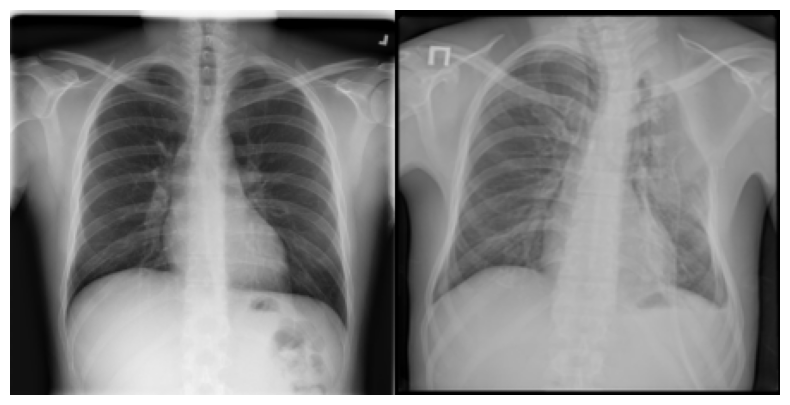

Normal Chest X-Ray Vs Tuberculosis Chest X-Ray


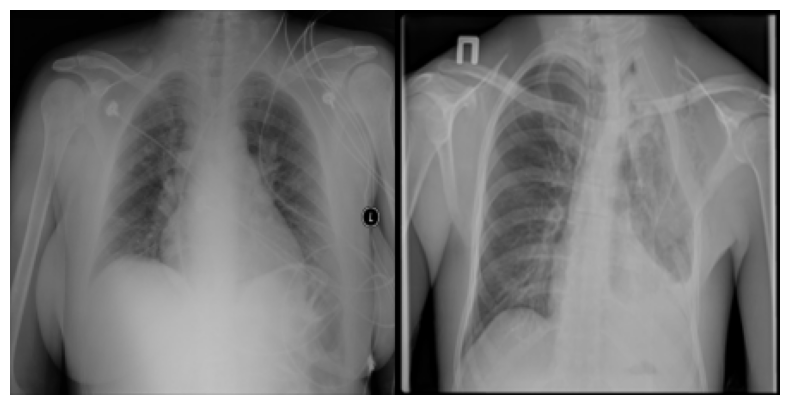

Normal Chest X-Ray Vs Tuberculosis Chest X-Ray


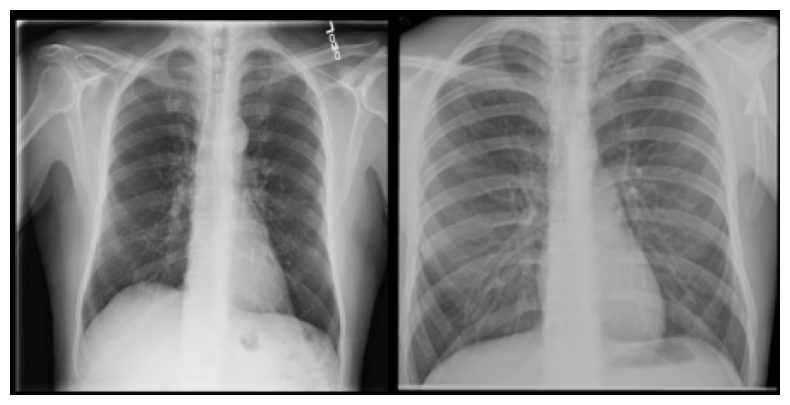

Normal Chest X-Ray Vs Tuberculosis Chest X-Ray


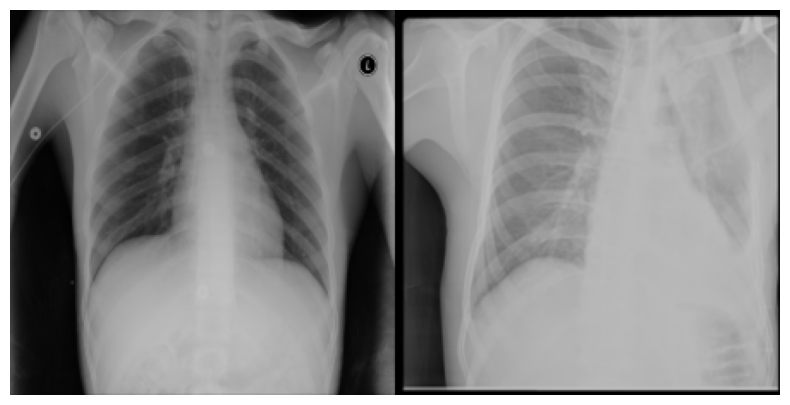

In [ ]:
def plotter(i):
    normal_path = Data_Dir + "Normal/" + Nimages[i]
    tb_path = Data_Dir + "Tuberculosis/" + TBimages[i]

    normal = cv2.imread(normal_path)
    tb = cv2.imread(tb_path)

    #normal = skimage.transform.resize(normal, (224,224, 3))
    #tb = skimage.transform.resize(tb, (224,224, 3) , mode = 'reflect')

    if normal is not None and tb is not None:
        #normal = cv2.resize(normal, (224, 224))  # Resize to target size
        normal = skimage_transform.resize(normal, (224,224, 3))
        #tb = cv2.resize(tb, (224, 224))
        tb = skimage_transform.resize(tb, (224,224, 3) , mode = 'reflect')

         # Convert the images to uint8 before concatenating
        normal = (normal * 255).astype(np.uint8)
        tb = (tb * 255).astype(np.uint8)

        pair = np.concatenate((normal, tb), axis=1)

        print("Normal Chest X-Ray Vs Tuberculosis Chest X-Ray")
        plt.figure(figsize=(10, 5))  # Adjust the size for better visualization
        plt.imshow(cv2.cvtColor(pair, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    else:
        print(f"Error loading images at index {i}")

for i in range(5):
    plotter(i)


In [ ]:
TBimages = len(os.listdir(os.path.join(Data_Dir+"Tuberculosis")))
Nimages = len(os.listdir(os.path.join(Data_Dir+"Normal")))
print("Length of Tuberculosis images:",TBimages)
print("Length of Normal images:",Nimages)

Length of Tuberculosis images: 700
Length of Normal images: 700


In [ ]:
dataset = "/content/drive/MyDrive/700-700/"
args={}
args["dataset"]=dataset

In [ ]:
ipaths = list(paths.list_images(args["dataset"]))
data = []
labels = []

for ipath in ipaths:
    label = ipath.split(os.path.sep)[-2]  # Extract the label from the path
    image = cv2.imread(ipath)  # Read the image
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert image to RGB
    image = cv2.resize(image, (224, 224))  # Resize image to 224x224

    data.append(image)  # Append the processed image to the data list
    labels.append(label)  # Append the label to the labels list

# Convert lists to numpy arrays once after the loop
data = np.array(data) / 255.0  # Normalize the image data
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)


Data shape: (1400, 224, 224, 3)
Labels shape: (1400,)


In [ ]:
LB = LabelBinarizer()  #Initialize label binarizer
labels = LB.fit_transform(labels)
labels = to_categorical(labels)
print(labels)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [ ]:
# split between Training and Test Image
XN_train, XN_test, YN_train, YN_test = train_test_split(data, labels, test_size=0.27,
                                                        random_state = np.random.randint(1,1000, 1)[0])

In [ ]:
# Split between Training and Validation Images.
X_train, X_test, Y_train, Y_test = train_test_split(XN_train, YN_train, test_size=0.22,
                                                    random_state = np.random.randint(1,1000, 1)[0])

In [ ]:
# Number of Images in training and test images Network
print(" Training & Val Images in XN Train class:",XN_train.shape)
print(" Training & Val Images in YN Train class:",YN_train.shape)
print(" Training Images in X Train class:",X_train.shape)
print(" Training Images in Y Train class:",Y_train.shape)
print(" Val Images in X Test class:",X_test.shape)
print(" Val Images in Y Test class:",Y_test.shape)
print(" Test Images in XN Test class:",XN_test.shape)
print(" Test Images in YN Test class:",YN_test.shape)

 Training & Val Images in XN Train class: (1022, 224, 224, 3)
 Training & Val Images in YN Train class: (1022, 2)
 Training Images in X Train class: (797, 224, 224, 3)
 Training Images in Y Train class: (797, 2)
 Val Images in X Test class: (225, 224, 224, 3)
 Val Images in Y Test class: (225, 2)
 Test Images in XN Test class: (378, 224, 224, 3)
 Test Images in YN Test class: (378, 2)


In [ ]:
positional_emb = True
conv_layers = 2
projection_dim = 128

num_heads = 2    #2
transformer_units = [
    projection_dim,
    projection_dim,
]
transformer_layers = 2  #2
stochastic_depth_rate = 0.1

learning_rate = 0.001
weight_decay = 0.0001
batch_size = 16  #16
num_epochs = 100
image_size = 224

In [ ]:
class CCTTokenizer(layers.Layer):
    def __init__(
        self,
        kernel_size=3,
        stride=1,
        padding=1,
        pooling_kernel_size=3,
        pooling_stride=2,
        num_conv_layers=conv_layers,
        num_output_channels=[64, 128],
        positional_emb=positional_emb,
        **kwargs,
    ):
        super().__init__(**kwargs)

        # This is our tokenizer.
        self.conv_model = keras.Sequential()
        for i in range(num_conv_layers):
            self.conv_model.add(
                layers.Conv2D(
                    num_output_channels[i],
                    kernel_size,
                    stride,
                    padding="valid",
                    use_bias=False,
                    activation="relu",
                    kernel_initializer="he_normal",
                )
            )
            self.conv_model.add(layers.ZeroPadding2D(padding))
            self.conv_model.add(
                layers.MaxPooling2D(pooling_kernel_size, pooling_stride, "same")
            )

        self.positional_emb = positional_emb

    def call(self, images):
        outputs = self.conv_model(images)
        # After passing the images through our mini-network the spatial dimensions
        # are flattened to form sequences.
        reshaped = keras.ops.reshape(
            outputs,
            (
                -1,
                keras.ops.shape(outputs)[1] * keras.ops.shape(outputs)[2],
                keras.ops.shape(outputs)[-1],
            ),
        )
        return reshaped


In [ ]:
class PositionEmbedding(keras.layers.Layer):
    def __init__(
        self,
        sequence_length,
        initializer="glorot_uniform",
        **kwargs,
    ):
        super().__init__(**kwargs)
        if sequence_length is None:
            raise ValueError("`sequence_length` must be an Integer, received `None`.")
        self.sequence_length = int(sequence_length)
        self.initializer = keras.initializers.get(initializer)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "sequence_length": self.sequence_length,
                "initializer": keras.initializers.serialize(self.initializer),
            }
        )
        return config

    def build(self, input_shape):
        feature_size = input_shape[-1]
        self.position_embeddings = self.add_weight(
            name="embeddings",
            shape=[self.sequence_length, feature_size],
            initializer=self.initializer,
            trainable=True,
        )

        super().build(input_shape)

    def call(self, inputs, start_index=0):
        shape = keras.ops.shape(inputs)
        feature_length = shape[-1]
        sequence_length = shape[-2]
        # trim to match the length of the input sequence, which might be less
        # than the sequence_length of the layer.
        position_embeddings = keras.ops.convert_to_tensor(self.position_embeddings)
        position_embeddings = keras.ops.slice(
            position_embeddings,
            (start_index, 0),
            (sequence_length, feature_length),
        )
        return keras.ops.broadcast_to(position_embeddings, shape)

    def compute_output_shape(self, input_shape):
        return input_shape


In [ ]:
class SequencePooling(layers.Layer):
    def __init__(self):
        super().__init__()
        self.attention = layers.Dense(1)

    def call(self, x):
        attention_weights = keras.ops.softmax(self.attention(x), axis=1)
        attention_weights = keras.ops.transpose(attention_weights, axes=(0, 2, 1))
        weighted_representation = keras.ops.matmul(attention_weights, x)
        return keras.ops.squeeze(weighted_representation, -2)


In [ ]:
# Referred from: github.com:rwightman/pytorch-image-models.
class StochasticDepth(layers.Layer):
    def __init__(self, drop_prop, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prop
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, x, training=None):
        if training:
            keep_prob = 1 - self.drop_prob
            shape = (keras.ops.shape(x)[0],) + (1,) * (len(x.shape) - 1)
            random_tensor = keep_prob + keras.random.uniform(
                shape, 0, 1, seed=self.seed_generator
            )
            random_tensor = keras.ops.floor(random_tensor)
            return (x / keep_prob) * random_tensor
        return x


In [ ]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.ops.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


In [ ]:
# Note the rescaling layer. These layers have pre-defined inference behavior.
data_augmentation = keras.Sequential(
    [
        layers.Rescaling(scale=1.0 / 255),
        layers.RandomCrop(image_size, image_size),
        layers.RandomFlip("horizontal"),
    ],
    name="data_augmentation",
)

In [ ]:
def create_cct_model(
    image_size=image_size,
    input_shape=(224, 224, 3),
    num_heads=num_heads,
    projection_dim=projection_dim,
    transformer_units=transformer_units,
    num_classes=2
):
    inputs = layers.Input(input_shape)

    # Augment data.
    augmented = data_augmentation(inputs)

    # Encode patches.
    cct_tokenizer = CCTTokenizer()
    encoded_patches = cct_tokenizer(augmented)

    # Apply positional embedding.
    if positional_emb:
        sequence_length = encoded_patches.shape[1]
        encoded_patches += PositionEmbedding(sequence_length=sequence_length)(
            encoded_patches
        )

    # Calculate Stochastic Depth probabilities.
    dpr = [x for x in np.linspace(0, stochastic_depth_rate, transformer_layers)]

    # Create multiple layers of the Transformer block.
    for i in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-5)(encoded_patches)

        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)

        # Skip connection 1.
        attention_output = StochasticDepth(dpr[i])(attention_output)
        x2 = layers.Add()([attention_output, encoded_patches])

        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-5)(x2)

        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)

        # Skip connection 2.
        x3 = StochasticDepth(dpr[i])(x3)
        encoded_patches = layers.Add()([x3, x2])

    # Apply sequence pooling.
    representation = layers.LayerNormalization(epsilon=1e-5)(encoded_patches)
    weighted_representation = SequencePooling()(representation)

    # Classify outputs.
    logits = layers.Dense(num_classes)(weighted_representation)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model


In [ ]:
# Define per-fold score containers for Test
acc_per_fold = []
loss_per_fold = []

In [ ]:
# Define per-fold score containers for Train
acc_per_fold1 = []
loss_per_fold1 = []

In [ ]:
# Define per-fold score containers for Train
acc_per_fold2 = []
loss_per_fold2 = []

In [ ]:
# Merge inputs and targets
inputs = np.concatenate((X_train, X_test), axis=0)
targets = np.concatenate((Y_train, Y_test), axis=0)

In [ ]:
# Define the K-fold Cross Validator
num_folds = 5
kfold = KFold(n_splits=num_folds,shuffle=True)

In [ ]:
# Define some callbacks
pat = 10 #this is the number of epochs with no improvment after which the training will stop
verbosity = 1
early_stopping = EarlyStopping(monitor='val_loss', patience=pat, verbose=1)

In [ ]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)


    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(
            from_logits=True, label_smoothing=0.1
        ),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy")
        ],
    )

     # Initialize ReduceLROnPlateau callback
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',    # Monitor validation loss for improvement
        factor=0.2,            # Reduce the learning rate by a factor of 0.2
        patience=5,            # Wait for 5 epochs before reducing the rate
        min_lr=0.00001         # Set the minimum learning rate
    )


    #checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    #checkpoint_callback = keras.callbacks.ModelCheckpoint(
        #checkpoint_filepath,
        #monitor="val_accuracy",
        #save_best_only=True,
        #save_weights_only=True,
    #)

    # K-fold Cross Validation model evaluation
    fold_no = 1
    global R
    R=[]
    for train, test in kfold.split(inputs, targets):

        print(f'Training for fold {fold_no} ...')
        R.append(model.fit(inputs[train], targets[train],batch_size=batch_size,epochs=num_epochs,verbose=verbosity,
                     validation_data=(inputs[test], targets[test]), callbacks=[early_stopping]))

        print('--------------------- Training Data-------------------------------')
        scores1 = model.evaluate(inputs[train], targets[train], verbose=0)
        print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores1[0]}; {model.metrics_names[1]} of {scores1[1]*100}%')
        acc_per_fold1.append(scores1[1] * 100)
        loss_per_fold1.append(scores1[0])

        print('-------------------- Validation Data-------------------------------')
        scores = model.evaluate(inputs[test], targets[test], verbose=0)
        print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores[0]}; {model.metrics_names[1]} of {scores[1]*100}%')
        acc_per_fold.append(scores[1] * 100)
        loss_per_fold.append(scores[0])

        print('--------------------- Test Data-------------------------------')
        scores2= model.evaluate(XN_test, YN_test, verbose=0)
        print(f'Score for fold {fold_no}: {model.metrics_names[0]} of {scores2[0]}; {model.metrics_names[1]} of {scores2[1]*100}%')
        acc_per_fold2.append(scores2[1] * 100)
        loss_per_fold2.append(scores2[0])

        # Increase fold number
        fold_no = fold_no + 1


    print('-------------------- Training Data-------------------------------')
    print('Score per fold')
    for i in range(0, len(acc_per_fold1)):
      print('------------------------------------------------------------------------')
      print(f'> Fold {i+1} - Loss: {loss_per_fold1[i]} - Accuracy: {acc_per_fold1[i]}%')
      print('------------------------------------------------------------------------')
      print('Average scores for all folds:')
      print(f'> Accuracy: {np.mean(acc_per_fold1)} (+- {np.std(acc_per_fold1)})')
      print(f'> Loss: {np.mean(loss_per_fold1)}')
      print('------------------------------------------------------------------------')


    print('-------------------- Validation Data-------------------------------')
    print('Score per fold')
    for i in range(0, len(acc_per_fold)):
      print('------------------------------------------------------------------------')
      print(f'> Fold {i+1} - Loss: {loss_per_fold[i]} - Accuracy: {acc_per_fold[i]}%')
      print('------------------------------------------------------------------------')
      print('Average scores for all folds:')
      print(f'> Accuracy: {np.mean(acc_per_fold)} (+- {np.std(acc_per_fold)})')
      print(f'> Loss: {np.mean(loss_per_fold)}')
      print('------------------------------------------------------------------------')


    print('-------------------- Test Data-------------------------------')
    print('Score per fold')
    for i in range(0, len(acc_per_fold2)):
      print('------------------------------------------------------------------------')
      print(f'> Fold {i+1} - Loss: {loss_per_fold2[i]} - Accuracy: {acc_per_fold2[i]}%')
      print('------------------------------------------------------------------------')
      print('Average scores for all folds:')
      print(f'> Accuracy: {np.mean(acc_per_fold2)} (+- {np.std(acc_per_fold2)})')
      print(f'> Loss: {np.mean(loss_per_fold2)}')
      print('------------------------------------------------------------------------')

    #history = model.fit(
        #x=X_train,
        #y=Y_train,
        #batch_size=batch_size,
        #epochs=num_epochs,
        #validation_data=(X_test, Y_test),
        #callbacks=[checkpoint_callback],
    #)

    #model.load_weights(checkpoint_filepath)
    #_, accuracy = model.evaluate(XN_test, YN_test)

    # Print the test accuracy
    #print(f"Test accuracy: {round(accuracy * 100, 2)}%")

    #return history

    return model


cct_model = create_cct_model()
trained_model = run_experiment(cct_model)

Training for fold 1 ...
Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 59s 831ms/step - accuracy: 0.5019 - loss: 0.8276 - val_accuracy: 0.6488 - val_loss: 0.5733
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 74s 839ms/step - accuracy: 0.5233 - loss: 0.7144 - val_accuracy: 0.7171 - val_loss: 0.5461
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 40s 774ms/step - accuracy: 0.6978 - loss: 0.5774 - val_accuracy: 0.7415 - val_loss: 0.5360
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 41s 781ms/step - accuracy: 0.7102 - loss: 0.5683 - val_accuracy: 0.7220 - val_loss: 0.5572
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 41s 780ms/step - accuracy: 0.7118 - loss: 0.5535 - val_accuracy: 0.6756 - val_loss: 0.6166
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 43s 821ms/step - accuracy: 0.6298 - loss: 0.6114 - val_accuracy: 0.7366 - val_loss: 0.5413
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 41s 780ms/step - accuracy: 0.7036 - loss: 0.5667 - val_accuracy: 0.6098 - val_loss: 0.5835
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 41s 777ms/step - accuracy: 

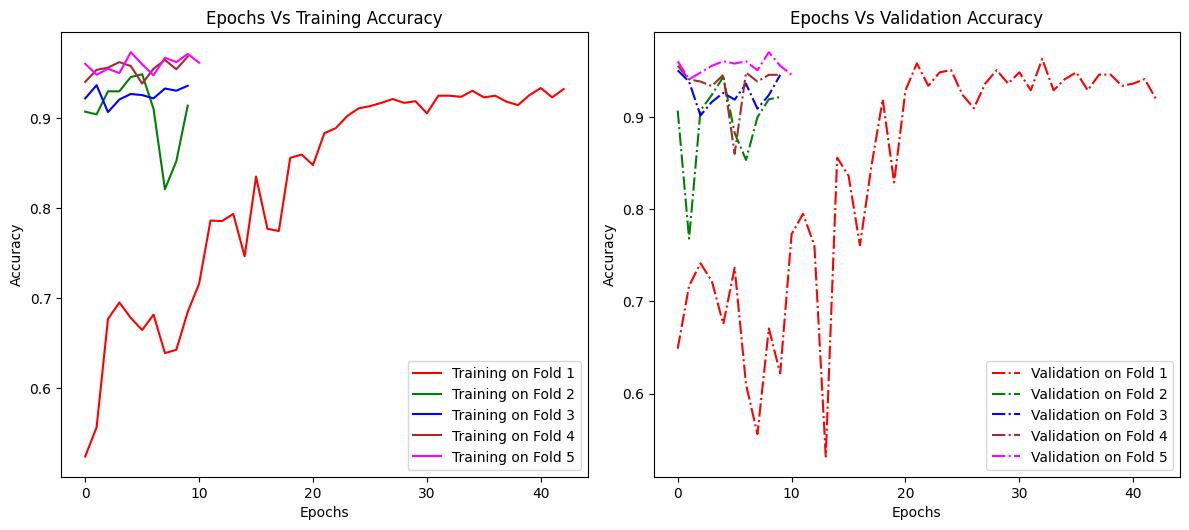

In [ ]:
# plot losses and accuracies for training and validation-G1
global R
fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot(2, 2, 1)
plt.title('Epochs Vs Training Accuracy')
plt.plot(R[0].history['accuracy'], label='Training on Fold 1', color='red')
plt.plot(R[1].history['accuracy'], label='Training on Fold 2', color='green')
plt.plot(R[2].history['accuracy'], label='Training on Fold 3', color='blue')
plt.plot(R[3].history['accuracy'], label='Training on Fold 4', color='brown')
plt.plot(R[4].history['accuracy'], label='Training on Fold 5', color='magenta')

ax.set_ylabel("Accuracy")
ax.set_xlabel("Epochs")
plt.legend(loc='best')


ax = fig.add_subplot(2, 2, 2)
plt.title('Epochs Vs Validation Accuracy')
plt.plot(R[0].history['val_accuracy'], label='Validation on Fold 1', color='red', linestyle='dashdot')
plt.plot(R[1].history['val_accuracy'], label='Validation on Fold 2', color='green', linestyle='dashdot')
plt.plot(R[2].history['val_accuracy'], label='Validation on Fold 3', color='blue', linestyle='dashdot')
plt.plot(R[3].history['val_accuracy'], label='Validation on Fold 4', color='brown', linestyle='dashdot')
plt.plot(R[4].history['val_accuracy'], label='Validation on Fold 5', color='magenta', linestyle='dashdot')
ax.set_ylabel("Accuracy")
ax.set_xlabel('Epochs')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

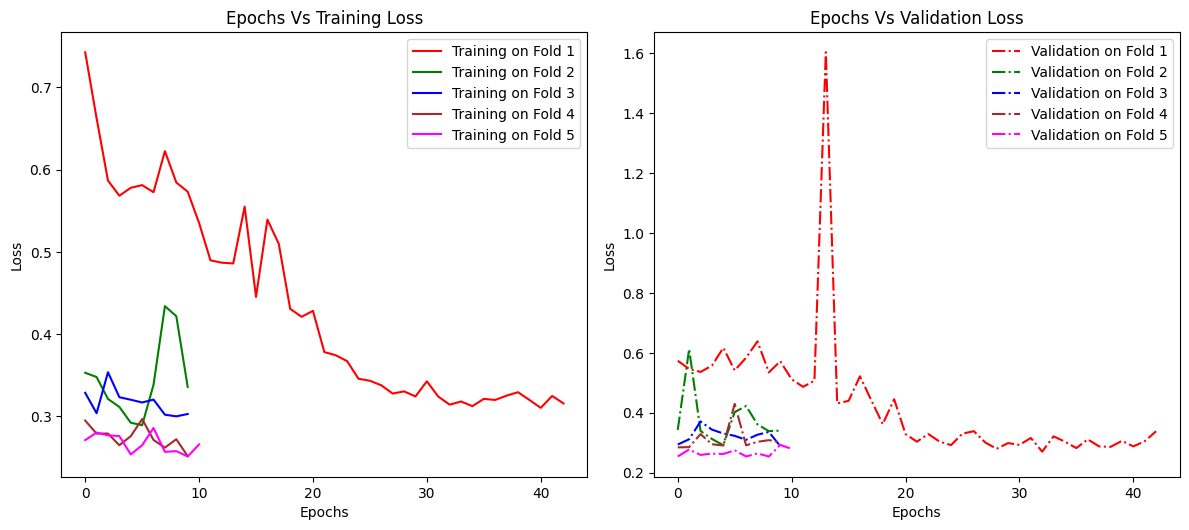

In [ ]:
# plot losses for training and validation-G2
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(2, 2, 1)
plt.title('Epochs Vs Training Loss')
plt.plot(R[0].history['loss'], label='Training on Fold 1', color='red')
plt.plot(R[1].history['loss'], label='Training on Fold 2', color='green')
plt.plot(R[2].history['loss'], label='Training on Fold 3', color='blue')
plt.plot(R[3].history['loss'], label='Training on Fold 4', color='brown')
plt.plot(R[4].history['loss'], label='Training on Fold 5', color='magenta')

ax.set_ylabel("Loss")
ax.set_xlabel("Epochs")
plt.legend(loc='best')

ax = fig.add_subplot(2, 2, 2)
plt.title('Epochs Vs Validation Loss')
plt.plot(R[0].history['val_loss'], label='Validation on Fold 1', color='red', linestyle='dashdot')
plt.plot(R[1].history['val_loss'], label='Validation on Fold 2', color='green', linestyle='dashdot')
plt.plot(R[2].history['val_loss'], label='Validation on Fold 3', color='blue', linestyle='dashdot')
plt.plot(R[3].history['val_loss'], label='Validation on Fold 4', color='brown', linestyle='dashdot')
plt.plot(R[4].history['val_loss'], label='Validation on Fold 5', color='magenta', linestyle='dashdot')

ax.set_ylabel("Loss")
ax.set_xlabel('Epochs')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# Validation classification_report
from sklearn.metrics import classification_report
y_pred = trained_model.predict(X_test, batch_size=batch_size)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(Y_test.argmax(axis=1), y_pred,target_names=LB.classes_))

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.97       115
Tuberculosis       1.00      0.93      0.96       110

    accuracy                           0.96       225
   macro avg       0.97      0.96      0.96       225
weighted avg       0.97      0.96      0.96       225



In [ ]:
# Test classification_report
from sklearn.metrics import classification_report
yn_pred = trained_model.predict(XN_test, batch_size=batch_size)
yn_pred = np.argmax(yn_pred, axis=1)
print(classification_report(YN_test.argmax(axis=1), yn_pred,target_names=LB.classes_))

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       198
Tuberculosis       0.98      0.93      0.95       180

    accuracy                           0.96       378
   macro avg       0.96      0.95      0.95       378
weighted avg       0.96      0.96      0.95       378



In [ ]:
 # Validation Performance Metrices-1
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test.argmax(axis=1), y_pred)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
precision = cm[0, 0] / (cm [0, 0] + cm [1, 0])
f1score = 2*recall*precision / (recall + precision)
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))
print("recall: {:.4f}".format(recall))
print("precision: {:.4f}".format(precision))
print("f1score: {:.4f}".format(f1score))

[[115   0]
 [  8 102]]
acc: 0.9644
sensitivity: 1.0000
specificity: 0.9273
recall: 1.0000
precision: 0.9350
f1score: 0.9664


In [ ]:
# Test Performance Metrices-1
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(YN_test.argmax(axis=1), yn_pred)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
precision = cm[0, 0] / (cm [0, 0] + cm [1, 0])
f1score = 2*recall*precision / (recall + precision)
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))
print("recall: {:.4f}".format(recall))
print("precision: {:.4f}".format(precision))
print("f1score: {:.4f}".format(f1score))

[[194   4]
 [ 13 167]]
acc: 0.9550
sensitivity: 0.9798
specificity: 0.9278
recall: 0.9798
precision: 0.9372
f1score: 0.9580


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step


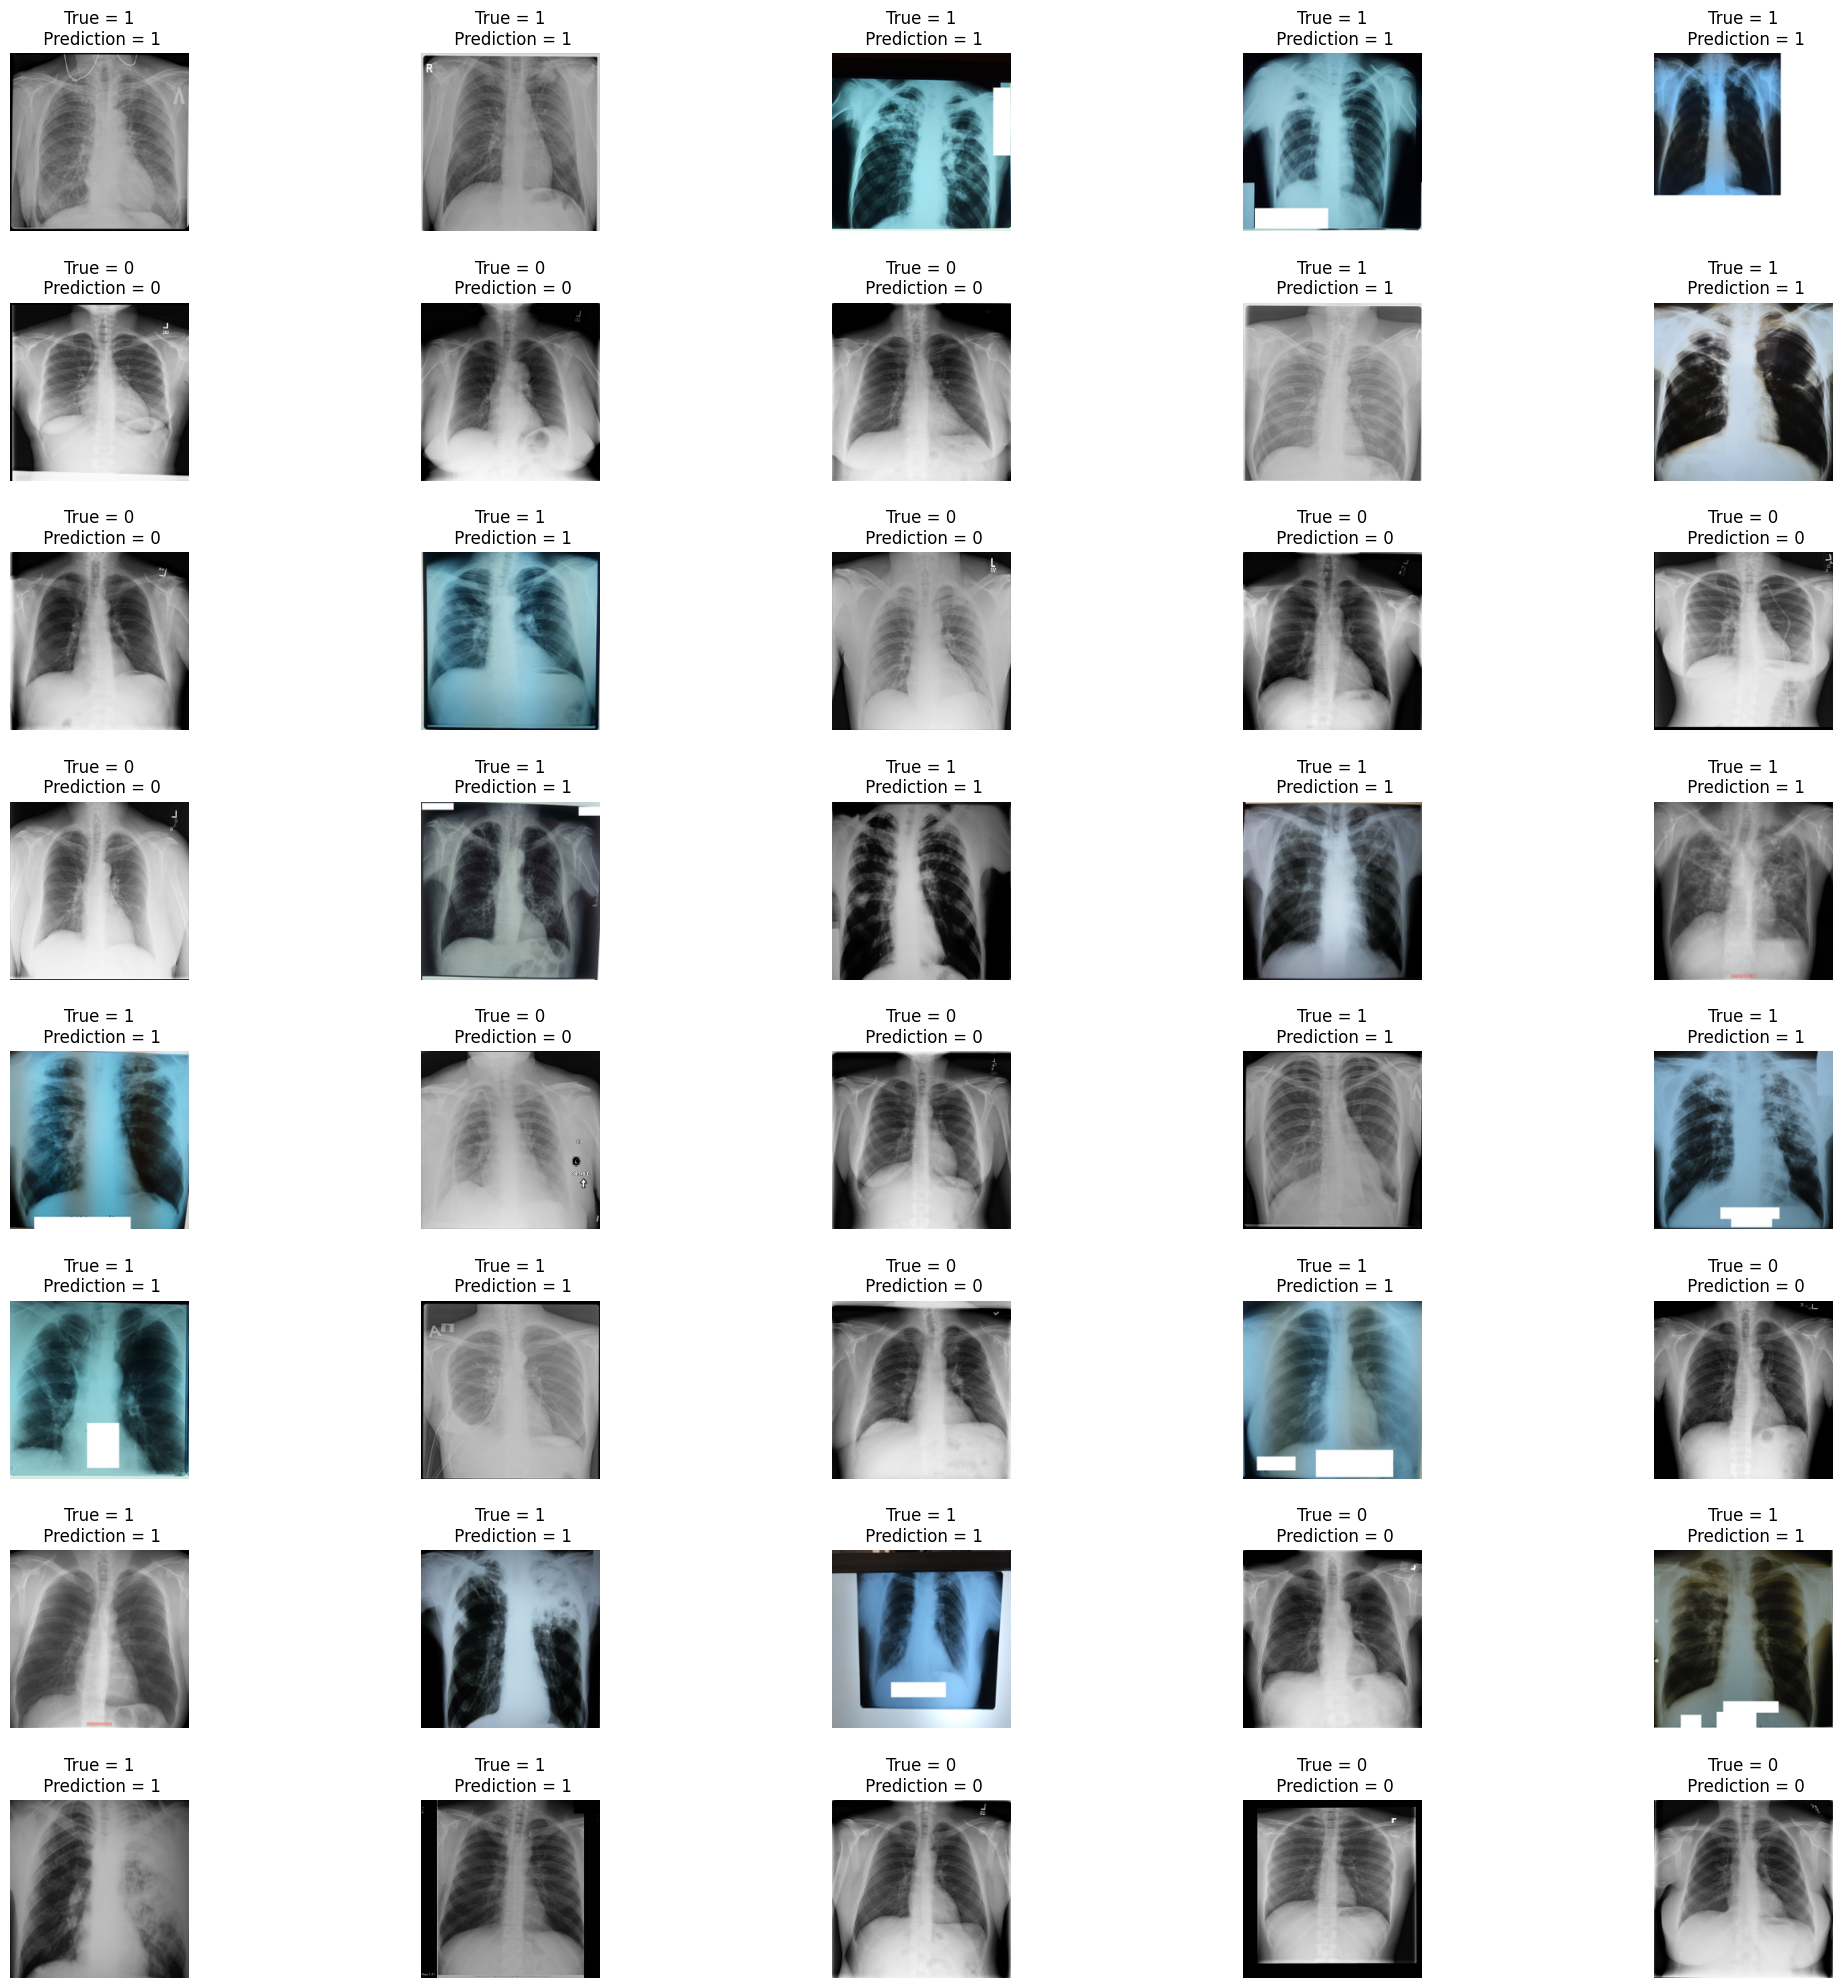

In [ ]:
# Validation Prediction Results-Grid Mode(13/06)
L = 8
W = 5
fig, axes = plt.subplots(L, W, figsize = (25,25))
axes = axes.ravel()
y_pred = trained_model.predict(X_test, batch_size=batch_size)
for i in np.arange(0,L*W):
    axes[i].imshow(X_test[i])
    axes[i].set_title('True = {}\n Prediction = {}'.format(Y_test.argmax(axis=1)[i],y_pred.argmax(axis=1)[i]))
    axes[i].axis('off')
plt.subplots_adjust(wspace = 0.4, hspace=0.4)

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step


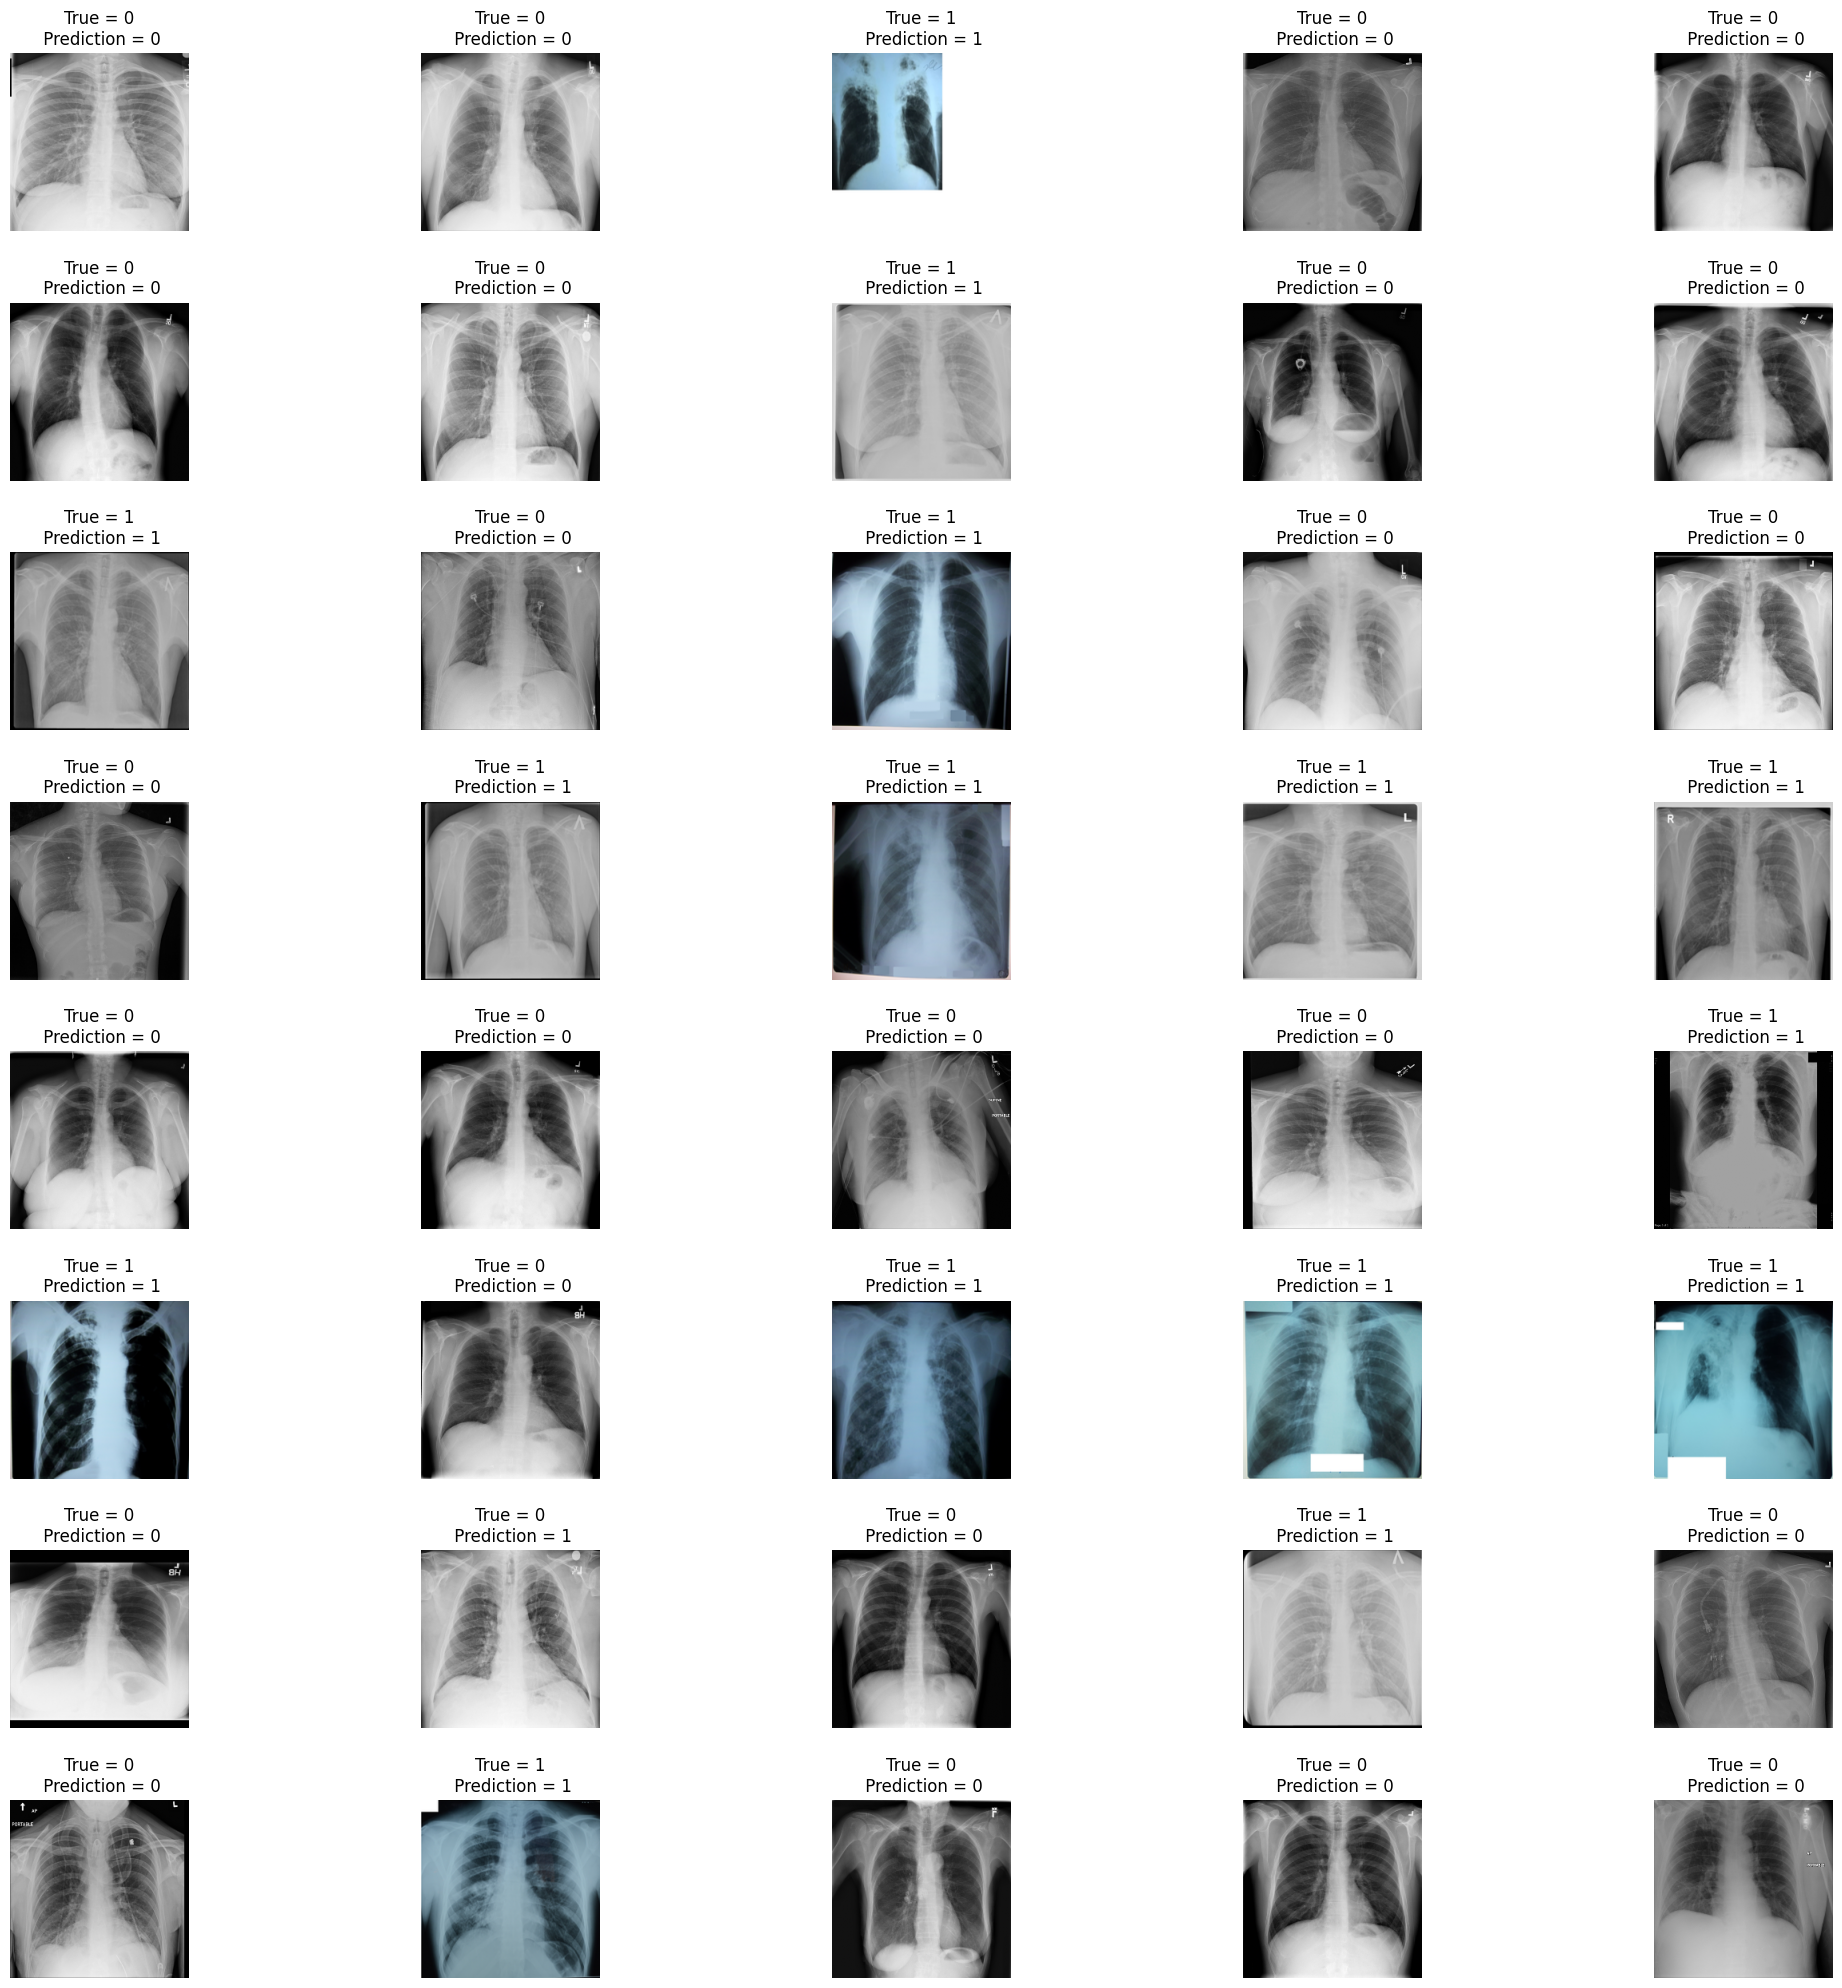

In [ ]:
# Test Prediction Results-Grid Mode (13/06)
L = 8
W = 5
fig, axes = plt.subplots(L, W, figsize = (25,25))
axes = axes.ravel()
yn_pred = trained_model.predict(XN_test, batch_size=batch_size)
for i in np.arange(0,L*W):
    axes[i].imshow(XN_test[i])
    axes[i].set_title('True = {}\n Prediction = {}'.format(YN_test.argmax(axis=1)[i],yn_pred.argmax(axis=1)[i]))
    axes[i].axis('off')
plt.subplots_adjust(wspace = 0.4, hspace=0.4)